In [13]:
import os
import os.path as osp
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import dsrl.infos as dsrl_infos

### Simple Confidence Plot

In [112]:
DATA_PATH="/mnt/d/books/iitm/phd/offline_mpc/weighted_bc"

In [113]:
def convert_to_melt_df(algo, task, type, algo_name):
    # load csv to dataframe
    path = f"{DATA_PATH}/{algo}/{task}/{type}"
    abs_filenames = sorted([osp.join(path, f) for f in os.listdir(path)])
    dfs = []
    for i, f in enumerate(abs_filenames):
        d = pd.read_csv(f)
        if "Wall time" not in d.columns:
            continue 
        d = d.drop(columns=["Wall time"]).rename(columns={"Value": f"seed_{i}", "Step": "epoch"})
        dfs.append(d)
 
    # join dataframes based on epoch
    df = dfs[0]
    for d in dfs[1:]:
        df = df.join(d.set_index("epoch"), on="epoch")
        
    df = pd.melt(df, id_vars=["epoch"], var_name="algo_name", value_name=type)
    df["algo_name"] = algo_name
    return df

In [ ]:
task = "Point_Circle1"
type = "ep_cost"

# positive_bc_df = convert_to_melt_df("positive_bc", task, type, "positive_bc")
mix_50p_01_df = convert_to_melt_df("50p_mix_0.1", task, type, "50p_bc_0.1")
mix_50p_03_df = convert_to_melt_df("50p_mix_0.3", task, type, "50p_bc_0.3")
mix_50p_05_df = convert_to_melt_df("50p_mix_0.5", task, type, "50p_bc_0.5")
mix_50p_07_df = convert_to_melt_df("50p_mix_0.7", task, type, "50p_bc_0.7")

In [ ]:
d = pd.concat([mix_50p_01_df, mix_50p_03_df, mix_50p_05_df, mix_50p_07_df], ignore_index=True, sort=False)

Text(0.5, 1.0, 'Point_Circle1')

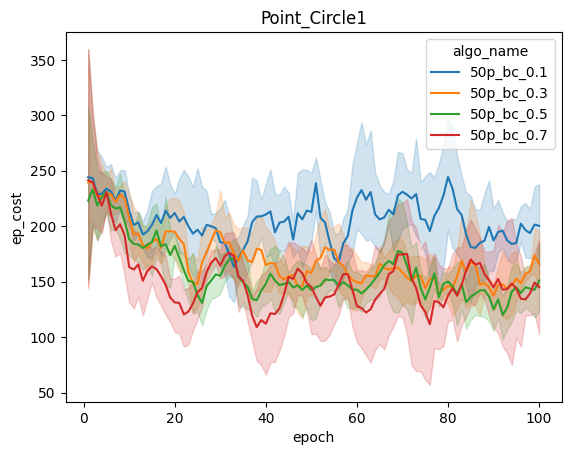

In [ ]:
fig, ax = plt.subplots()

sns.lineplot(ax=ax, data=d, x="epoch", y=type, hue="algo_name")
sns.move_legend(ax, "upper right")
ax.set_title(task)

In [ ]:
save_fig_path = f"{DATA_PATH}/svg_images/{task}_{type}.svg"
fig.savefig(save_fig_path, format="svg")

In [ ]:
save_fig_path = f"{DATA_PATH}/png_images/{task}_{type}.png"
fig.savefig(save_fig_path)

### Bootstrap Confidence Interval

In [14]:
algotype = "safemil"
# DATA_PATH = f"/mnt/d/books/iitm/phd/offline_mpc/{algotype}/"
DATA_PATH = "/home/returaj/Documents/research/offline_safe_rl/neg_pos/aaai_2026"

In [15]:
def load_data_as_array(hyperparams, algo, task, type):
    # load csv to dataframe
    # path = f"{DATA_PATH}/{algo}/{task}/{type}"
    path = f"{DATA_PATH}/{hyperparams}/{algo}/{task}/{type}"
    abs_filenames = sorted([osp.join(path, f) for f in os.listdir(path)])
    dfs = []
    for i, f in enumerate(abs_filenames):
        d = pd.read_csv(f)
        # if "Wall time" not in d.columns:
        #     continue 
        # d = d.drop(columns=["Wall time"])
        d = d.rename(columns={"Value": f"seed_{i}"})
        dfs.append(d)
 
    # join dataframes based on Step
    df = dfs[0]
    for d in dfs[1:]:
        df = df.join(d.set_index("Step"), on="Step", how="right")
    
    df = df.drop(columns=["Step"])
    df = df.reset_index(drop=True)
    for col in df.columns:
        avg = (df[col].shift(1) + df[col].shift(-1)) / 2
        df[col] = df[col].where(df[col].notna(), avg)
        if pd.isna(df.at[0, col]):
            df.at[0, col] = df.at[1, col]
        if pd.isna(df.at[len(df) - 1, col]):
            df.at[len(df) - 1, col] = df.at[len(df) - 2, col]
    
    # num_seeds X T
    arr = df.to_numpy().T
    return arr

In [16]:
def normalize_reward(arr, baseline, env_name):
    env_name = env_name.replace("_", "")
    # max_reward = dsrl_infos.MAX_EPISODE_REWARD[env_name]
    min_reward = dsrl_infos.MIN_EPISODE_REWARD[env_name]
    return (arr - min_reward) / (baseline - min_reward)
    # return arr

def normalize_cost(arr, baseline, env_name):
    # return (arr+1)/ (baseline+1)
    return arr - baseline
    # return arr

In [17]:
def bootstrap_confidence_interval(data, n_bootstrap=1000, confidence_level=0.95):
    """
    Function to compute bootstrap confidence intervals for time-series data and plot the results.
    
    Parameters:
    data (list of array-like): List of n time-series datasets (arrays) of the same length.
    n_bootstrap (int): Number of bootstrap resamples.
    confidence_level (float): Confidence level for the interval (default is 0.95).
    
    Returns:
    mean, lower_bound, upper_bound: The lower and upper bounds of the confidence interval at each time step.
    """
    # Convert data to numpy array (shape: 5 x T, where T is the number of time steps)
    data = np.array(data)
    
    # Ensure all time-series are of the same length
    assert len(set([len(ts) for ts in data])) == 1, "All time-series must be of the same length!"
    
    # Number of time steps
    num_data, T = data.shape
    
    # Arrays to store bootstrap results
    bootstrapped_means = np.zeros((n_bootstrap, T))
    
    # Perform bootstrap resampling for each time step
    for i in range(n_bootstrap):
        # Resample with replacement from the num_data time-series at each time step
        resampled_indices = np.random.choice(num_data, (num_data,), replace=True)
        bootstrapped_means[i, :] = np.mean(data[resampled_indices], axis=0)
    
    # Compute the confidence interval at each time step
    alpha = (1 - confidence_level) / 2
    lower_bound = np.percentile(bootstrapped_means, 100 * alpha, axis=0)
    upper_bound = np.percentile(bootstrapped_means, 100 * (1 - alpha), axis=0)
    
    mean_time_series = np.mean(bootstrapped_means, axis=0)

    return mean_time_series, lower_bound, upper_bound

In [18]:
def light_color(color, amount=0.7):
    try:
        c = mcolors.cnames[color]  # convert named color to hex
    except KeyError:
        c = color  # if it's not a named color, it might already be hex or RGB

    rgb = mcolors.to_rgb(c)  # convert to RGB format
    light_color = [(1 - amount) * channel + amount for channel in rgb]  # blend with white
    return light_color

def plot_confidence_interval(means, lowers, uppers, labels, colors, markers, title, xlabel, ylabel,
                             axis=None, is_ylabel=True, is_xlabel=True, is_title=True):
    ax = axis
    if axis is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    T = min([len(x) for x in means]) #len(means[0])
    x = ((np.arange(T) + 1) * 2) / 100
    for m, l, u, label, c, marker in zip(means, lowers, uppers, labels, colors, markers):
        linestyle = '-'
        if np.all(m == l) == 1:
            linestyle = "--"
            ax.plot(x, m[:T], color=c, lw=2.5, label=label, linestyle=linestyle)
        else:
            ax.plot(x, m[:T], color=c, lw=2.5, label=label, linestyle=linestyle,
                    marker=marker, markevery=5, markersize=9)
            ax.fill_between(x, l[:T], u[:T], color=light_color(c), alpha=0.4)
    
    if is_title:
        ax.set_title(title, fontsize='xx-large')
    if is_ylabel:
        ax.set_ylabel(ylabel, fontsize='xx-large')
    if is_xlabel:
        ax.set_xlabel(xlabel, fontsize='xx-large')
    # if ylabel == "ep_reward":
    #     ax.set_ylim([0.0, 1.6])
    ax.grid(visible=True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax.tick_params(axis='both', which='major', labelsize=12)
    # if ylabel in ("ep_reward", "ep_valid_bc"):
    #     ax.legend(loc='lower right')
    # elif ylabel in ("ep_cost",):
    #     ax.legend(loc="upper right")  
    if axis is None:    
        return fig, ax
    else:
        return ax
    

def plot_bar_confidence_interval(means, lowers, uppers, labels, colors, title, xlabel, ylabel,
                                 axis=None, is_ylabel=True, is_xlabel=True, is_title=True):
    del colors, xlabel
    
    colors = ["orange", "green"]
    ax = axis
    if axis is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    
    last_m = [m[-1] for m in means]
    last_l = [l[-1] for l in lowers]
    last_u = [u[-1] for u in uppers]

    yerr = np.array([
        np.array(last_m) - np.array(last_l),
        np.array(last_u) - np.array(last_m)
    ])

    xgap = 1.5
    xpos = np.arange(len(labels))*xgap

    bars = ax.bar(xpos, last_m, yerr=yerr, capsize=8, color=colors, edgecolor='black')
    ax.set_xticks(xpos)
    
    if is_title:
        ax.set_title(title, fontsize='xx-large')
    if is_ylabel:
        ax.set_ylabel(ylabel, fontsize='xx-large')
    if is_xlabel:
        ax.set_xticklabels(labels, fontsize='xx-large')
        for bar, label in zip(bars, labels):
            bar.set_label(label)

    return ax
  

In [75]:
cmky_map = {
    "cornflowerblue": "#4F81BD",
    "orange": "#E69F00",
    "coral": "#D97662",
    "mediumseagreen": "#6BA66C",
    "orchid": "#B57BB3",
}

BASE_COLORS = ["black", cmky_map["cornflowerblue"], cmky_map["orange"], cmky_map["coral"],
               cmky_map["mediumseagreen"], cmky_map["orchid"], "purple", "red", "yellow", "pink"]

MARKERS = [None, 'o', 's', '^', 'd', '*']

In [76]:
HYPERPARAMS = "mix_50p"
ALGOS = [("coptidice", "Constrained-RL"), ("bc", "BC-Unlabeled"), ("dwbc/nu_0.5", "DWBC-NU"), ("ppl/hz_5", "T-REX-WBC"), ("safedice", "SafeDICE"), ("safemil/loss_1_bce/bag_128/hz_10", "SafeMIL (our)"),] #("safetd3/simultaneous/hz_5/lambda_0.25/valpha_0.01_vbeta_1.0/no_contrastive", "w/o contrastive"), ("safetd3/simultaneous/hz_5/lambda_0.25/valpha_0.01_vbeta_1.0/contrastive", "SafeTD3 (our)")]
# ALGOS = [("preferred_bc", "BC-Pref"), ("bc", "BC-Union"), ("ppl/hz_5", "ppl"), ("safedice", "safedice"), ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.005_vbeta_0.001", "w/o bootstrap"), ("safetd3/simultaneous/hz_5/lambda_0.25/valpha_0.005_vbeta_0.001/no_contrastive", "w/o contrastive"), ("safetd3/simultaneous/hz_5/lambda_0.25/valpha_0.005_vbeta_0.001/contrastive", "SafeTD3 (our)")]

# ALGOS = [("preferred_bc", "BC-Pref"), ("safetd3/pretrain/hz_5/lambda_0.25/valpha_0.01_vbeta_1.0", "pretrain"), ("safetd3/simultaneous/hz_5/lambda_0.25/valpha_0.01_vbeta_1.0/contrastive", "SafeTD3 (our)")]
# ALGOS = [("preferred_bc", "BC-Pref"), ("safetd3/pretrain/hz_5/lambda_0.25/valpha_0.01_vbeta_0.01", "pretrain"), ("safetd3/simultaneous/hz_5/lambda_0.25/valpha_0.005_vbeta_0.001/contrastive", "SafeTD3 (our)")]

# ALGOS = [("preferred_bc", "BC-Pref"), ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.01_vbeta_1.0", "w/o bootstrap"), ("safetd3/simultaneous/hz_5/lambda_0.25/valpha_0.01_vbeta_1.0/contrastive", "SafeTD3 (our)")]

# ALGOS = [
#     [("preferred_bc", "BC-Pref"), ("safemil/loss_1_bce_bc_transition/bag_128/hz_5", "transition_weighted"), ("safemil/loss_1_bce/bag_128/hz_5", "trajectory_weighted")],
#     [("preferred_bc", "BC-Pref"), ("safemil/loss_1_bce_bc_transition/bag_128/hz_10", "transition_weighted"), ("safemil/loss_1_bce/bag_128/hz_10", "trajectory_weighted")]
# ]

In [77]:
def generate_performance_figures(tasks):
    types = ("ep_reward", "ep_cost", "ep_worst_cost_0.2")
    num_tasks = len(tasks)
    single_fig, single_axs = plt.subplots(3, num_tasks, figsize=(20, 10), sharex='col')
    for y, task in enumerate(tasks):
        for x, type in enumerate(types):
            # preferred policy performance
            data = load_data_as_array(HYPERPARAMS, "coptidice", task, type)
            m, _, _ = bootstrap_confidence_interval(data)
            if type == "ep_reward":
                baseline = m[-1]
            else:
                baseline = m[-1]
            
            means, lowers, uppers, labels = [], [], [], []
            for a, suffix in ALGOS: # ALGOS[y]
                data = load_data_as_array(HYPERPARAMS, a, task, type)
                m, l, u = bootstrap_confidence_interval(data)
                if a == "coptidice":
                    m = l = u = np.ones_like(m) * baseline
                if type == "ep_reward":
                    m, l, u = (normalize_reward(x, baseline, task) for x in (m, l, u))
                else:
                    m, l, u = (normalize_cost(x, baseline, task) for x in (m, l, u))
                means.append(m)
                lowers.append(l)
                uppers.append(u)
                labels.append(suffix)
            colors = BASE_COLORS[:len(labels)]
            if type == "ep_cost":
                ylabel = "Normalized Cost"
            elif type == "ep_reward":
                ylabel = "Normalized Return"
            else:
                ylabel = "Normalized CVaR Cost"
            
            ax = plot_confidence_interval(means, lowers, uppers, labels=labels,
                                            colors=colors, markers=MARKERS, title=task.replace("_", " "), 
                                            xlabel="training steps " + r"$ \, (\times 10^6)$",
                                            ylabel=ylabel, axis=single_axs[x, y], is_ylabel=y==0, is_xlabel=x==2, is_title=x==0)

            # ax = plot_bar_confidence_interval(means, lowers, uppers, labels=labels,
            #                                 colors=colors, title=task.replace("_", " "), 
            #                                 xlabel="training steps " + r"$ \, (\times 10^6)$",
            #                                 ylabel=ylabel, axis=single_axs[x, y], is_ylabel=y==0, is_xlabel=x==2, is_title=x==0)
    plt.subplots_adjust(hspace=0.15) 
    return single_fig, single_axs

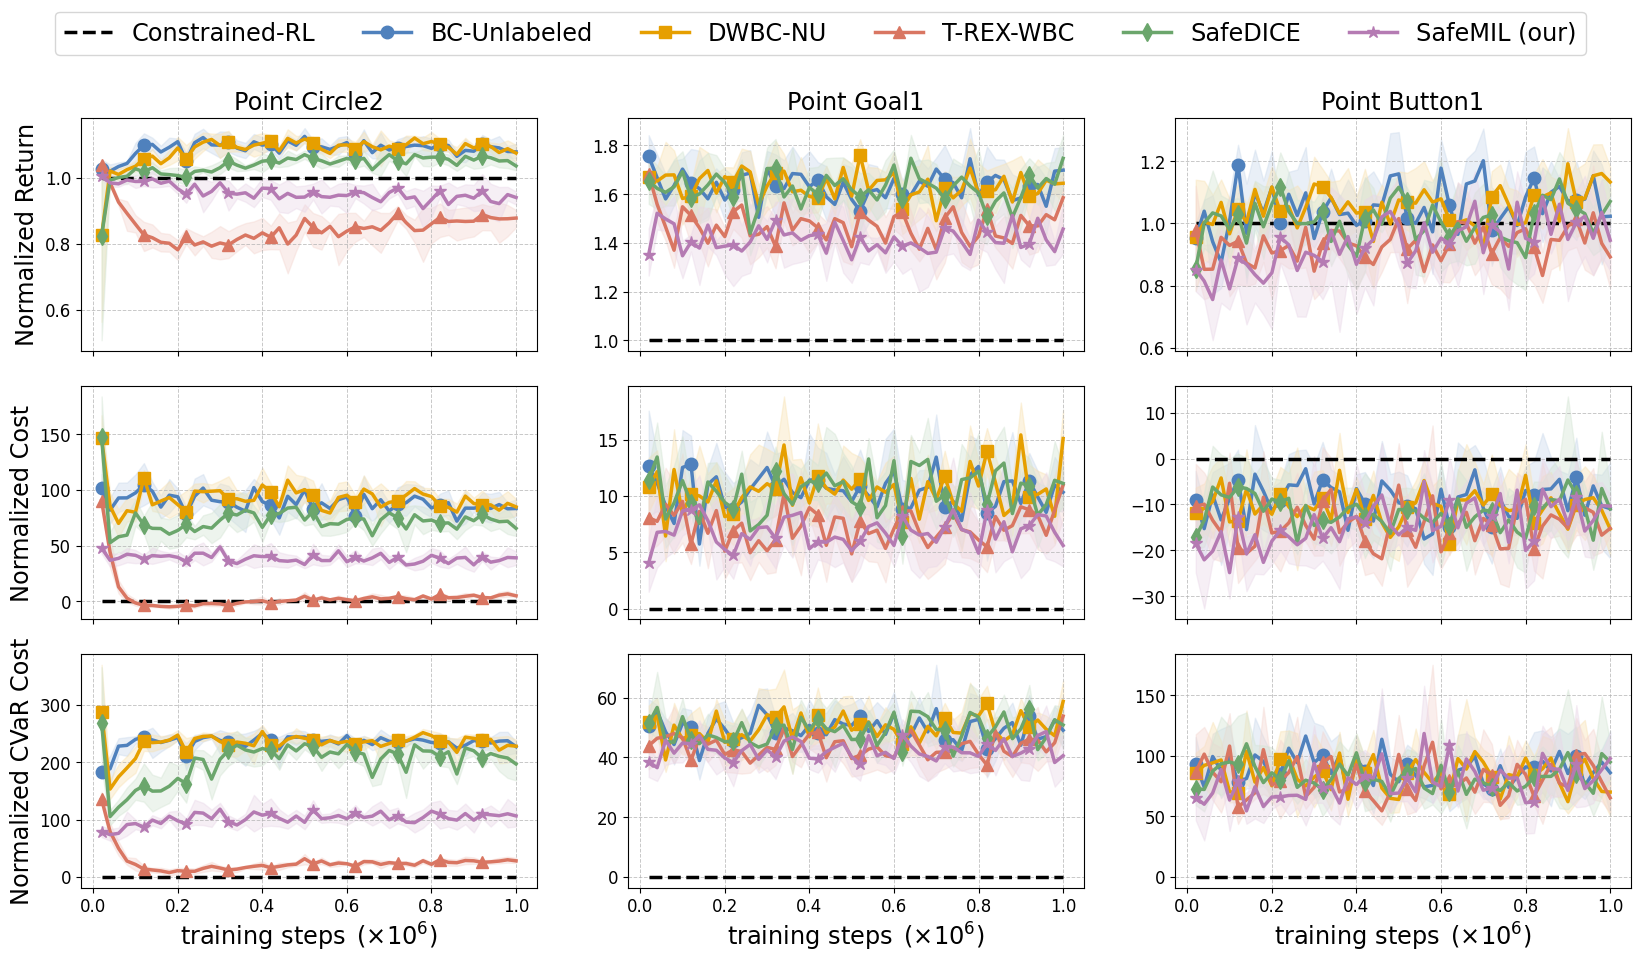

In [78]:
key="performance_comparison"
tasks = ["Point_Circle2", "Point_Goal1", "Point_Button1"] # Point_Push1
# tasks = ["Walker2d_Velocity", "Swimmer_Velocity", "Ant_Velocity"] # Hopper_Velocity
fig, ax = generate_performance_figures(tasks)
handles, labels = ax[0, 0].get_legend_handles_labels()
# Create a single legend for all subplots
fig.legend(handles, labels, loc='upper center', ncol=len(ALGOS), fontsize='xx-large')

### this helps in plotting ablation plots for this you need to uncomment bar plot function in "generate_performance_figures"
### and use ALGOs variable from ablation study section.
# key="ablation_study"
# # tasks = ["Point_Circle2", "Point_Goal1", "Point_Button1"] # Point_Push1
# tasks = ["Walker2d_Velocity", "Swimmer_Velocity", "Ant_Velocity"] # Hopper_Velocity
# fig, ax = generate_performance_figures(tasks)
# title='Ablation Study'
# fig.suptitle(title, fontsize=22)

#### Ablation Study

In [64]:
ALGOS = [("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.01_vbeta_1.0/no_contrastive", "w/o contrastive"), ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.01_vbeta_1.0/contrastive", "OSIL (our)")]
# ALGOS = [("preferred_bc", "BC-Pref"), ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.005_vbeta_0.001", "w/o bootstrap"), ("safetd3/simultaneous/hz_5/lambda_0.25/valpha_0.005_vbeta_0.001/no_contrastive", "w/o contrastive"), ("safetd3/simultaneous/hz_5/lambda_0.25/valpha_0.005_vbeta_0.001/contrastive", "SafeTD3 (our)")]

In [65]:
def plot_barplot(algorithms, means, lowers, uppers, ylabel, colors=None, axis=None):
    ax = axis
    yerr = np.array([
        np.array(means) - np.array(lowers),
        np.array(uppers) - np.array(means)
    ])
    
    xgap = 1.5
    xpos = np.arange(len(algorithms))*xgap

    bars = ax.bar(xpos, means, yerr=yerr, capsize=8, color=colors, edgecolor='black')
    ax.set_ylabel(ylabel, fontsize=18)

    ax.set_xticks(xpos)
    ax.set_xticklabels(algorithms, fontsize=18)

    for bar, label in zip(bars, algorithms):
        bar.set_label(label)
    
    return ax 

In [66]:
def ablation_bootstrap_interval(data, n_bootstrap=1000, confidence_level=0.95):
    data = np.array(data)
    
    assert len(set([len(ts) for ts in data])) == 1, "All time-series must be of the same length!"
    
    num_tasks, _ = data.shape
    tasks_mean = data.mean(axis=1)
    
    # Arrays to store bootstrap results
    bootstrapped = []
    
    # Perform bootstrap resampling for each seed
    for i in range(n_bootstrap):
        # Resample with replacement from the num_data time-series at each time step
        samples = np.random.choice(tasks_mean, (num_tasks,), replace=True)
        bootstrapped.append(samples.mean())
        
    # # Compute the confidence interval at each time step
    alpha = (1 - confidence_level) / 2
    lower_bound = np.percentile(bootstrapped, 100 * alpha)
    upper_bound = np.percentile(bootstrapped, 100 * (1 - alpha))
    
    mean = np.mean(tasks_mean)
    return mean, lower_bound, upper_bound


def generate_ablation(tasks, colors):
    types = ("ep_reward", "ep_cost", "ep_worst_cost_0.2")
    single_fig, single_axs = plt.subplots(1, 3, figsize=(20, 6), sharex='col')
    for y, type in enumerate(types):
        baseline_task = []
        for task in tasks:
            data = load_data_as_array(HYPERPARAMS, "preferred_bc", task, type)
            m, _, _ = bootstrap_confidence_interval(data)
            baseline_task.append(m[-1])

        means, lowers, uppers, suffixes = [], [], [], []
        for a, suffix in ALGOS:
            if a == "preferred_bc":
                continue
            algo_data = []
            for t, task in enumerate(tasks):
                data = load_data_as_array(HYPERPARAMS, a, task, type)
                if type == "ep_reward":
                    final_data = normalize_reward(data[:, -1], baseline_task[t], task)
                else:
                    final_data = normalize_cost(data[:, -1], baseline_task[t], task)
                algo_data.append(final_data)
            m, l, u = ablation_bootstrap_interval(algo_data)
            means.append(m), lowers.append(l), uppers.append(u)
            suffixes.append(suffix)
        
        if type == "ep_cost":
            ylabel = "Normalized Cost"
        elif type == "ep_reward":
            ylabel = "Normalized Return"
        else:
            ylabel = "Normalized CVaR Cost"
        ax = plot_barplot(algorithms=suffixes, means=means, lowers=lowers, uppers=uppers,
                          ylabel=ylabel, colors=colors, axis=single_axs[y])
    # plt.subplots_adjust(hspace=0.15) 
    return single_fig, single_axs
            

Text(0.5, 0.98, 'Ablation Study')

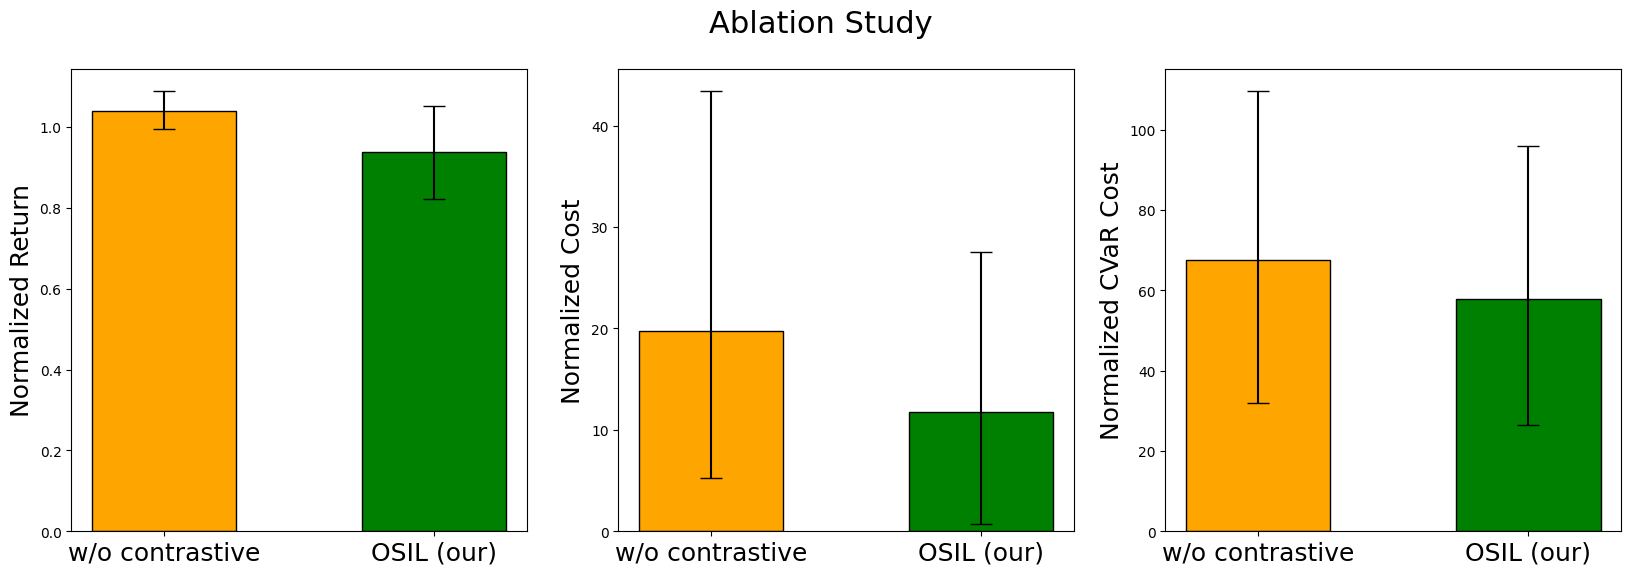

In [68]:
key = "ablation_study"

colors = ["orange", "green"]

# title = "Navigation Task"
# tasks = ["Point_Circle2", "Point_Goal1", "Point_Button1"] # Point_Push1

title = "Ablation Study"
tasks = ["Walker2d_Velocity", "Swimmer_Velocity", "Ant_Velocity"] + ["Point_Circle2", "Point_Goal1", "Point_Button1"] # Hopper_Velocity

fig, ax = generate_ablation(tasks, colors)
fig.suptitle(title, fontsize=22)

#### Impact of dataset size

In [50]:
ALGOS = [("coptidice", "Constrained-RL"), ("bc", "BC-Union"), ("ppl/hz_5", "PPL"), ("safedice", "SafeDICE"), ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.01_vbeta_1.0/contrastive", "OSIL (our)")]

In [51]:
def generate_dataset_size_figures(hyperparams, task):
    types = ("ep_reward", "ep_cost", "ep_worst_cost_0.2")
    num_hyperparams = len(hyperparams)
    single_fig, single_axs = plt.subplots(num_hyperparams, 3, figsize=(20, 15), sharex='col')
    for x, (hyperparam, hyperparam_suffix) in enumerate(hyperparams):
        for y, type in enumerate(types):
            # preferred policy performance
            data = load_data_as_array(hyperparam, "coptidice", task, type)
            m, _, _ = bootstrap_confidence_interval(data)
            if type == "ep_reward":
                baseline = m[-1]
            else:
                baseline = m[-1]

            means, lowers, uppers, labels = [], [], [], []
            for a, suffix in ALGOS: # ALGOS[y]
                data = load_data_as_array(hyperparam, a, task, type)
                m, l, u = bootstrap_confidence_interval(data, n_bootstrap=1000)
                if a == "coptidice":
                    m = l = u = np.ones_like(m) * baseline
                if type == "ep_reward":
                    m, l, u = (normalize_reward(x, baseline, task) for x in (m, l, u))
                else:
                    m, l, u = (normalize_cost(x, baseline, task) for x in (m, l, u))
                means.append(m)
                lowers.append(l)
                uppers.append(u)
                labels.append(suffix)
            colors = BASE_COLORS[:len(labels)]
            if type == "ep_cost":
                ylabel = "Normalized Cost"
            elif type == "ep_reward":
                ylabel = "Normalized Return"
            else:
                ylabel = "Normalized CVaR Cost"

            ax = plot_confidence_interval(means, lowers, uppers, labels=labels,
                                            colors=colors, title=hyperparam_suffix, 
                                            xlabel="training steps " + r"$ \, (\times 10^6)$",
                                            ylabel=ylabel, axis=single_axs[x, y], is_ylabel=True, is_xlabel=x==3, is_title=True)

            # ax = plot_bar_confidence_interval(means, lowers, uppers, labels=labels,
            #                                 colors=colors, title=hyperparam_suffix, 
            #                                 xlabel="training steps " + r"$ \, (\times 10^6)$",
            #                                 ylabel=ylabel, axis=single_axs[x, y], is_ylabel=y==0, is_xlabel=x==2, is_title=True)
    # plt.subplots_adjust(hspace=0.1) 
    return single_fig, single_axs

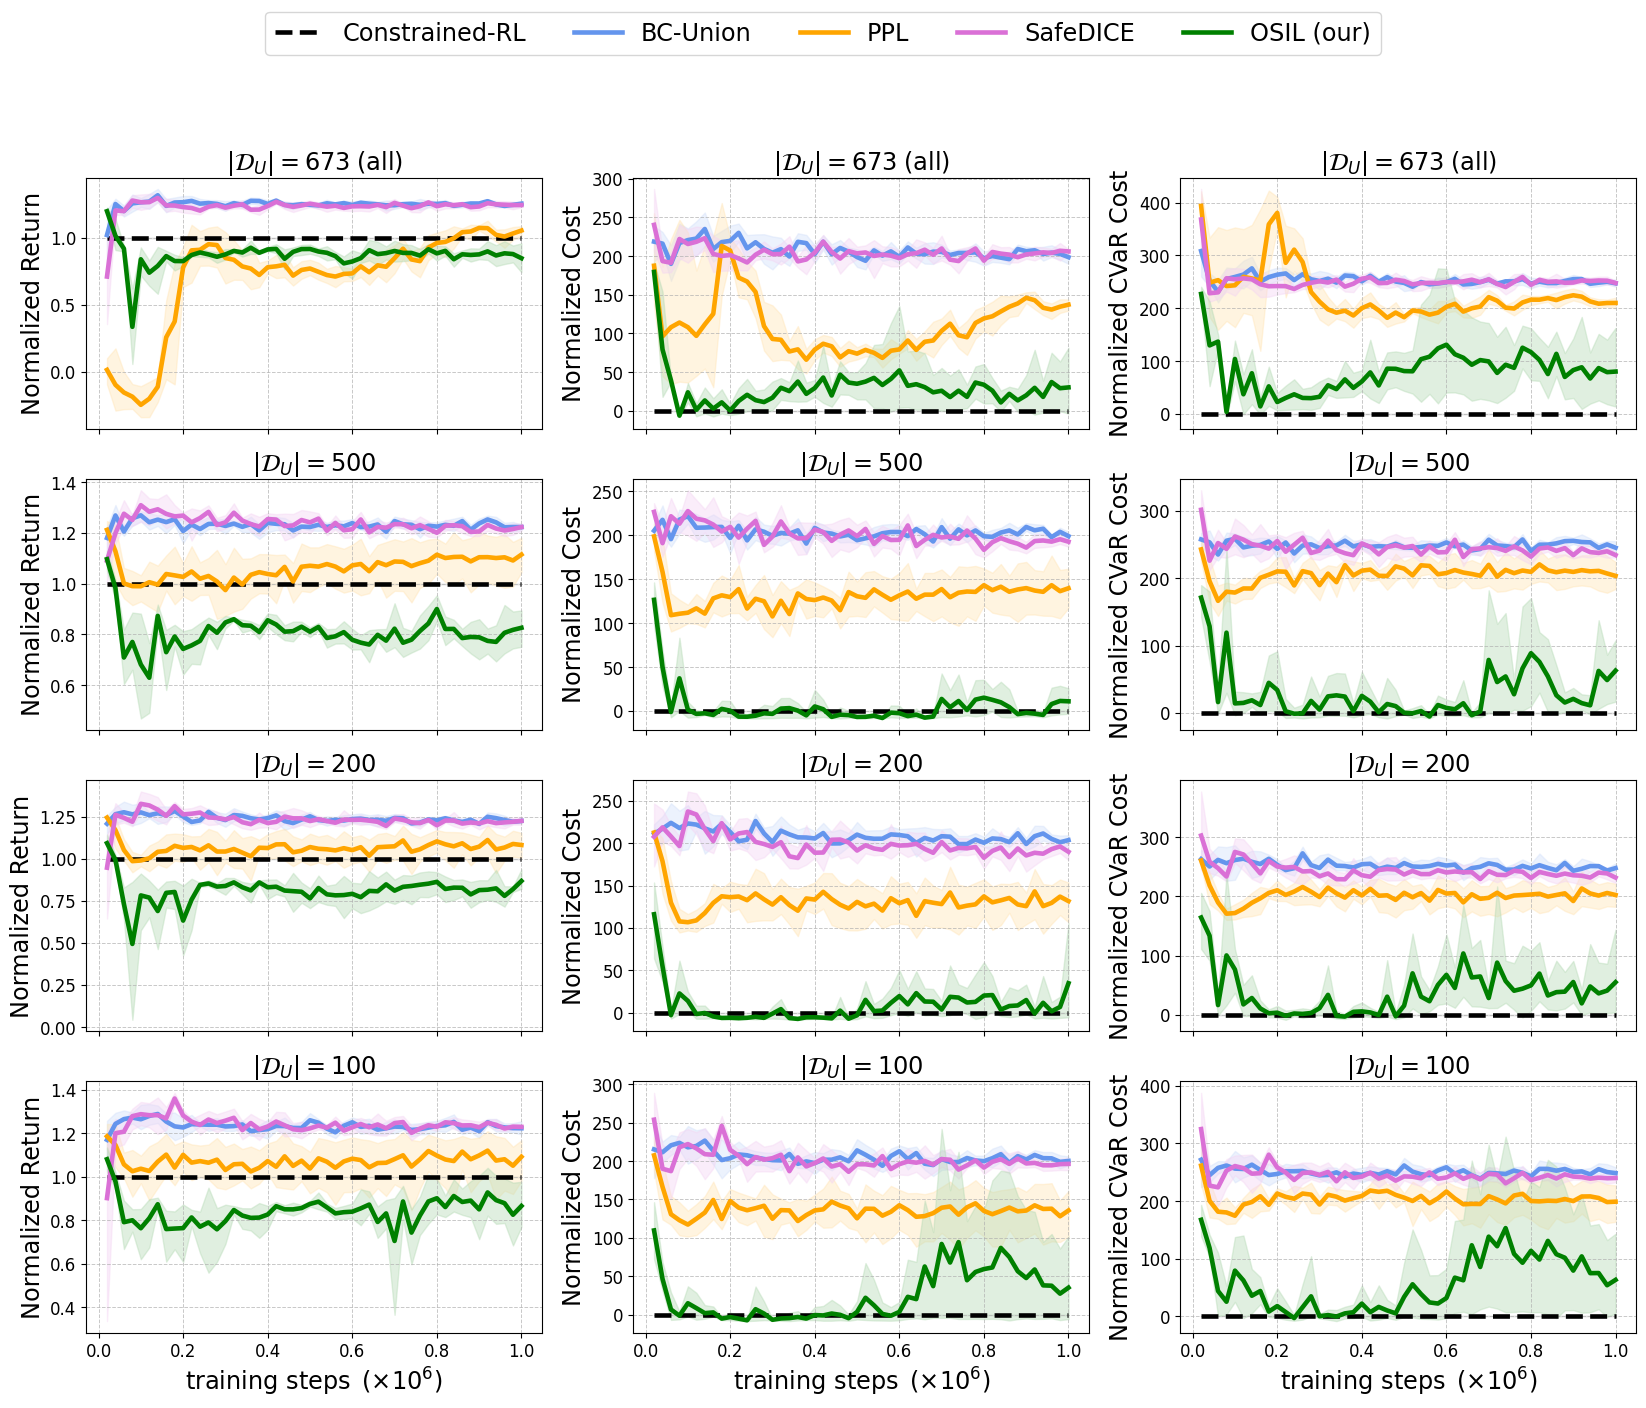

In [52]:
key="dataset_size"
task = "Point_Circle2"
hyperparams = [
    ("union_100", r"$|\mathcal{D}_U|=100$"),
    ("union_200", r"$|\mathcal{D}_U|=200$"),
    ("union_500", r"$|\mathcal{D}_U|=500$"),
    ("union_all", r"$|\mathcal{D}_U|=673\;(\text{all})$")
][::-1]
fig, ax = generate_dataset_size_figures(hyperparams, task)
handles, labels = ax[0, 0].get_legend_handles_labels()
# Create a single legend for all subplots
fig.legend(handles, labels, loc='upper center', ncol=len(ALGOS), fontsize='xx-large')

#### Sensitivity Plot

In [31]:
def plot_bar(means, lowers, uppers, x_axis, xlabel, ylabel, axis, is_ylabel, is_xlabel):
    lower_bar = [m-l for m,l in zip(means, lowers)]
    upper_bar = [u-m for m,u in zip(means, uppers)]
    # print(lower_bar, upper_bar)
    axis.errorbar(x_axis, means, yerr=[lower_bar, upper_bar], fmt='o-', capsize=5, color='blue')
    axis.plot(x_axis, means, color='red')
    if is_xlabel:
        axis.set_xlabel(xlabel, fontsize='xx-large')
    if is_ylabel:
        axis.set_ylabel(ylabel, fontsize='xx-large', color='blue')
    return axis


def add_time_figure(ax, algo, time_info):
    ax_twin = ax.twinx()
    
    x_axis = [t[1] for t in algo]
    y_axis = time_info #[x/time_info[0] for x in time_info]
    ax_twin.plot(x_axis, y_axis, 'ro--', linewidth=2)
    ax_twin.set_ylabel("Wall clock time (hr)", fontsize='xx-large', color='red')


def generate_sensitivity_figure(tasks, algos, key):
    types = ("ep_reward", "ep_cost", "ep_worst_cost_0.2")
    num_tasks = len(tasks)
    single_fig, single_axs = plt.subplots(1, 3, figsize=(20, 6), sharex='col')
    for y in range(num_tasks):
        task, algo = tasks[y], algos[y]
        for x, type in enumerate(types):
            # preferred policy performance
            data = load_data_as_array(HYPERPARAMS, "preferred_bc", task, type)
            m, _, _ = bootstrap_confidence_interval(data)
            baseline = np.mean(m)
            means, lowers, uppers = [], [], []
            for a, _ in algo: 
                data = load_data_as_array(HYPERPARAMS, a, task, type)
                m, l, u = bootstrap_confidence_interval(data)
                # if a == "preferred_bc":
                #     m = l = u = np.ones_like(m) * np.mean(m)
                if type == "ep_reward":
                    m, l, u = (normalize_reward(x, baseline, task) for x in (m, l, u))
                else:
                    m, l, u = (normalize_cost(x, baseline, task) for x in (m, l, u))
                means.append(m[-1])
                lowers.append(l[-1])
                uppers.append(u[-1])
            x_axis = [t[1] for t in algo]
            if type == "ep_cost":
                ylabel = "Normalized Cost"
            elif type == "ep_reward":
                ylabel = "Normalized Return"
            else:
                ylabel = "Normalized CVaR Cost"
            # ylabel = "Return" if type == "ep_reward" else "Cost"
            ax = plot_bar(means, lowers, uppers, x_axis=x_axis, 
                          xlabel=key, ylabel=ylabel, axis=single_axs[x],
                          is_ylabel=y==0, is_xlabel=x==1,)
            baseline = 1 if type == "ep_reward" else 0
            ax.plot(x_axis, baseline*np.ones(len(x_axis)), color='black', linestyle="--")
    plt.subplots_adjust(hspace=0.2) 
    return single_fig, single_axs

Text(0.5, 0.98, 'Point Circle2')

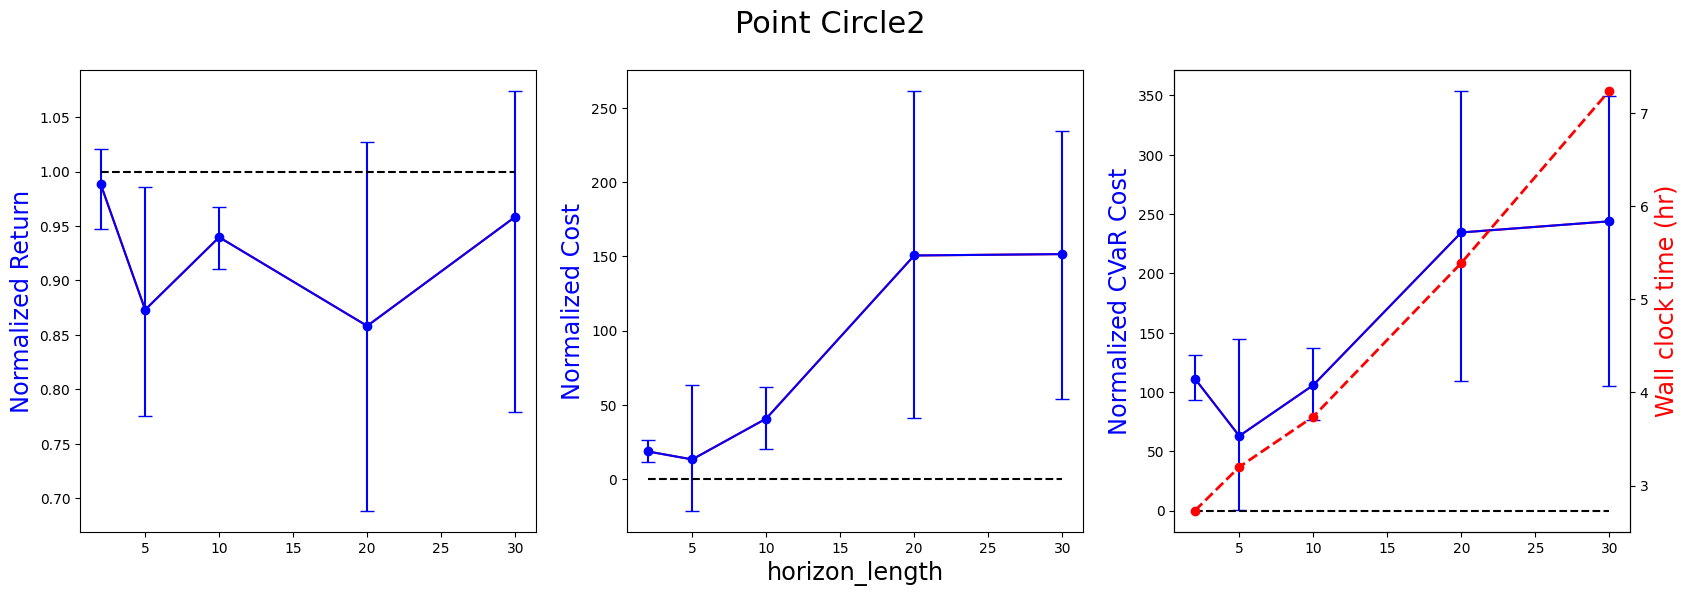

In [33]:
key = "horizon_length"
HYPERPARAMS = "neg_50"

tasks = ["Point_Circle2",]
# time_info = [6.5, 7.6, 8.9, 12.8, 17.2]
time_info = [2.73, 3.2, 3.74, 5.39, 7.24]

# tasks = ["Ant_Velocity",]

algos = [[
    ("safetd3/simultaneous/hz_2/lambda_0.0/valpha_0.01_vbeta_1.0/contrastive", 2),
    ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.01_vbeta_1.0/contrastive", 5),
    ("safetd3/simultaneous/hz_10/lambda_0.0/valpha_0.01_vbeta_1.0/contrastive", 10),
    ("safetd3/simultaneous/hz_20/lambda_0.0/valpha_0.01_vbeta_1.0/contrastive", 20),
    ("safetd3/simultaneous/hz_30/lambda_0.0/valpha_0.01_vbeta_1.0/contrastive", 30)
],]
fig, ax = generate_sensitivity_figure(tasks, algos, key)
add_time_figure(ax[-1], algos[0], time_info)
fig.suptitle(tasks[0].replace("_", " "), fontsize=22)

#### Sensitivity of lagrangian penalty

In [ ]:
def plot_bar(means, lowers, uppers, labels, colors, x_axis, xlabel, ylabel, axis, is_ylabel, is_xlabel):
    for t in range(len(means)):
        lower_bar = [m-l for m,l in zip(means[t], lowers[t])]
        upper_bar = [u-m for m,u in zip(means[t], uppers[t])]
        axis.errorbar(x_axis, means[t], yerr=[lower_bar, upper_bar],
                      fmt='o-', capsize=5, color=colors[t], label=labels[t])
    axis.set_xscale("log", base=10)
    if is_xlabel:
        axis.set_xlabel(xlabel, fontsize='xx-large')
    if is_ylabel:
        axis.set_ylabel(ylabel, fontsize='xx-large')
    return axis


def generate_lagrangian_sensitivity_figure(algos, xlabel, task):
    types = ("ep_reward", "ep_cost", "ep_worst_cost_0.2")
    num_tasks = len(tasks)
    single_fig, single_axs = plt.subplots(1, 3, figsize=(20, 6), sharex='col')
    for x, type in enumerate(types):
        # preferred policy performance
        data = load_data_as_array(HYPERPARAMS, "coptidice", task, type)
        m, _, _ = bootstrap_confidence_interval(data)
        baseline = np.mean(m[-1])
        means, lowers, uppers, labels = [], [], [], []
        for a_paths, algo_label in algos:
            mean, lower, upper = [], [], []
            for a, _ in a_paths:
                data = load_data_as_array(HYPERPARAMS, a, task, type)
                m, l, u = bootstrap_confidence_interval(data)
                # if a == "preferred_bc":
                #     m = l = u = np.ones_like(m) * np.mean(m)
                if type == "ep_reward":
                    m, l, u = (normalize_reward(x, baseline, task) for x in (m, l, u))
                else:
                    m, l, u = (normalize_cost(x, baseline, task) for x in (m, l, u))
                mean.append(m[-1])
                lower.append(l[-1])
                upper.append(u[-1])

            means.append(mean); lowers.append(lower); uppers.append(upper)
            labels.append(algo_label)
            x_axis = [t[1] for t in a_paths]

        colors = ["green", "orchid"]

        if type == "ep_cost":
            ylabel = "Normalized Cost"
        elif type == "ep_reward":
            ylabel = "Normalized Return"
        else:
            ylabel = "Normalized CVaR Cost"

        ax = plot_bar(means, lowers, uppers,labels, colors=colors, x_axis=x_axis, 
                      xlabel=xlabel, ylabel=ylabel, axis=single_axs[x],
                      is_ylabel=True, is_xlabel=x==1,)
        baseline = 1 if type == "ep_reward" else 0
        ax.plot(x_axis, baseline*np.ones(len(x_axis)), color='black', linestyle="--")
    plt.subplots_adjust(hspace=0.2) 
    return single_fig, single_axs

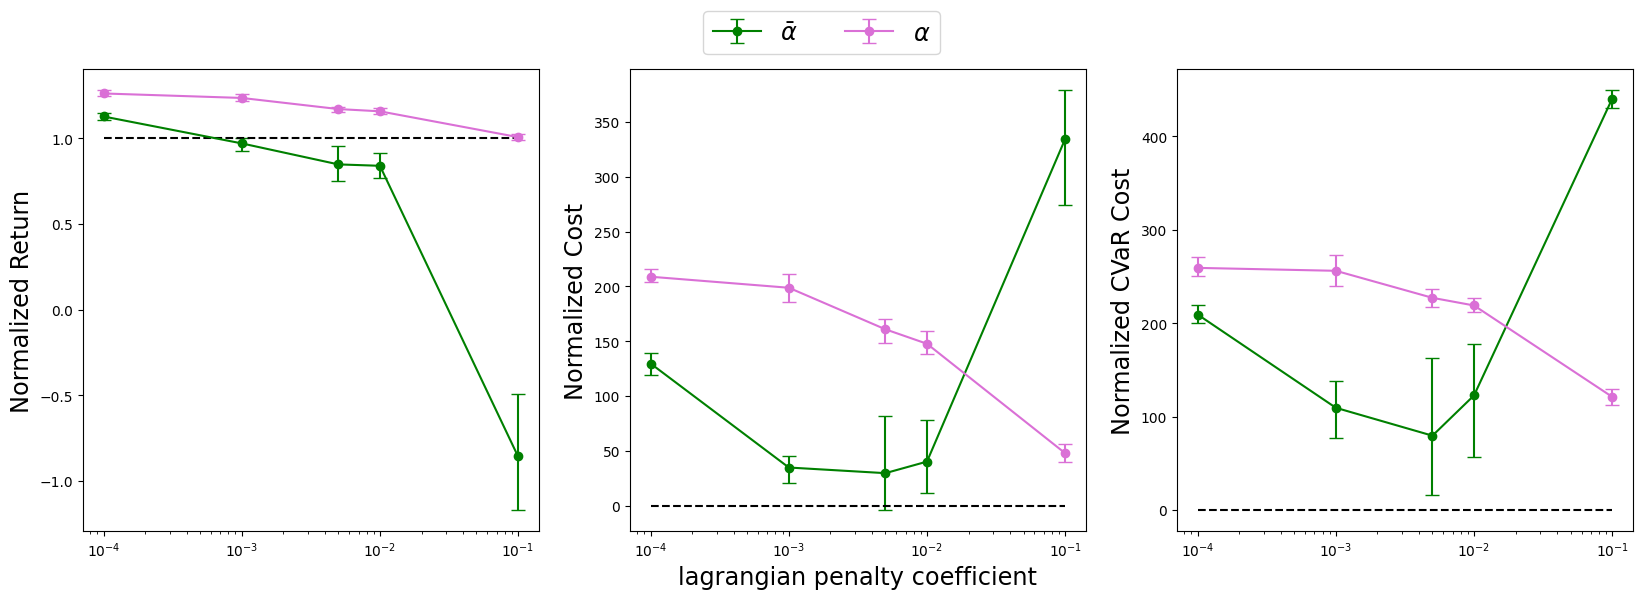

In [ ]:
key = "lagrangian_penalty"
xlabel = "Lagrangian Penalty Coefficient"
HYPERPARAMS = "neg_50"

task = "Point_Circle2"

algos = [
    (
        [
            ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.0001_vbeta_0.001/contrastive", 0.0001),
            ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.001_vbeta_0.001/contrastive", 0.001),
            ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.005_vbeta_0.001/contrastive", 0.005),
            ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.01_vbeta_0.001/contrastive", 0.01),
            ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.1_vbeta_0.001/contrastive", 0.1),
        ],
        r"$\bar{\alpha}$"
    ),
    (
        [
            ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.0001_vbeta_10000.0/contrastive", 0.0001),
            ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.001_vbeta_10000.0/contrastive", 0.001),
            ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.005_vbeta_10000.0/contrastive", 0.005),
            ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.01_vbeta_10000.0/contrastive", 0.01),
            ("safetd3/simultaneous/hz_5/lambda_0.0/valpha_0.1_vbeta_10000.0/contrastive", 0.1),
        ],
        r"$\alpha$"
    ),

]
fig, ax = generate_lagrangian_sensitivity_figure(algos, xlabel, task)
handles, labels = ax[0].get_legend_handles_labels()
# Create a single legend for all subplots
fig.legend(handles, labels, loc='upper center', ncol=len(algos), fontsize='xx-large')

#### [SafeMIL] Sensitivity Plot for Bag and Horizon length

In [27]:
def plot_bar(means, lowers, uppers, x_axis, title, xlabel, ylabel, axis, is_ylabel, is_xlabel, is_title):
    lower_bar = [m-l for m,l in zip(means, lowers)]
    upper_bar = [u-m for m,u in zip(means, uppers)]
    # print(lower_bar, upper_bar)
    axis.errorbar(x_axis, means, yerr=[lower_bar, upper_bar], fmt='o')
    axis.plot(x_axis, means, color='red')
    if is_title:
        axis.set_title(title, fontsize='xx-large')
    if is_xlabel:
        axis.set_xlabel(xlabel, fontsize='xx-large')
    if is_ylabel:
        axis.set_ylabel(ylabel, fontsize='xx-large')
    return axis


def generate_sensitivity_figure(tasks, algos, key):
    types = ("ep_reward", "ep_cost", "ep_worst_cost_0.2")
    num_tasks = len(tasks)
    single_fig, single_axs = plt.subplots(num_tasks, 3, figsize=(18, 5), sharex='col')
    for y in range(num_tasks):
        task, algo = tasks[y], algos[y]
        for x, type in enumerate(types):
            # preferred policy performance
            data = load_data_as_array(HYPERPARAMS, "coptidice", task, type)
            m, _, _ = bootstrap_confidence_interval(data)
            baseline = m[-1]
            means, lowers, uppers = [], [], []
            for a, _ in algo: 
                data = load_data_as_array(HYPERPARAMS, a, task, type)
                m, l, u = bootstrap_confidence_interval(data)
                # if a == "preferred_bc":
                #     m = l = u = np.ones_like(m) * np.mean(m)
                if type == "ep_reward":
                    m, l, u = (normalize_reward(x, baseline, task) for x in (m, l, u))
                else:
                    m, l, u = (normalize_cost(x, baseline, task) for x in (m, l, u))
                means.append(m[-1])
                lowers.append(l[-1])
                uppers.append(u[-1])
            x_axis = [t[1] for t in algo]
            # ylabel = "Normalized Return" if type == "ep_reward" else "Normalized Cost"
            # ylabel = "Return" if type == "ep_reward" else "Cost"
            if type == "ep_cost":
                ylabel = "Normalized Cost"
            elif type == "ep_reward":
                ylabel = "Normalized Return"
            else:
                ylabel = "Normalized CVaR Cost"
            ax = plot_bar(means, lowers, uppers, x_axis=x_axis, 
                          title=task.replace("_", " "), xlabel=key, ylabel=ylabel, axis=single_axs[x],
                          is_ylabel=y==0, is_xlabel=True, is_title=False)
            baseline = 1 if type == "ep_reward" else 0
            ax.plot(x_axis, baseline*np.ones(len(x_axis)), color='black', linestyle="--")
    plt.subplots_adjust(hspace=0.2) 
    return single_fig, single_axs

Text(0.5, 0.98, 'Point Goal1')

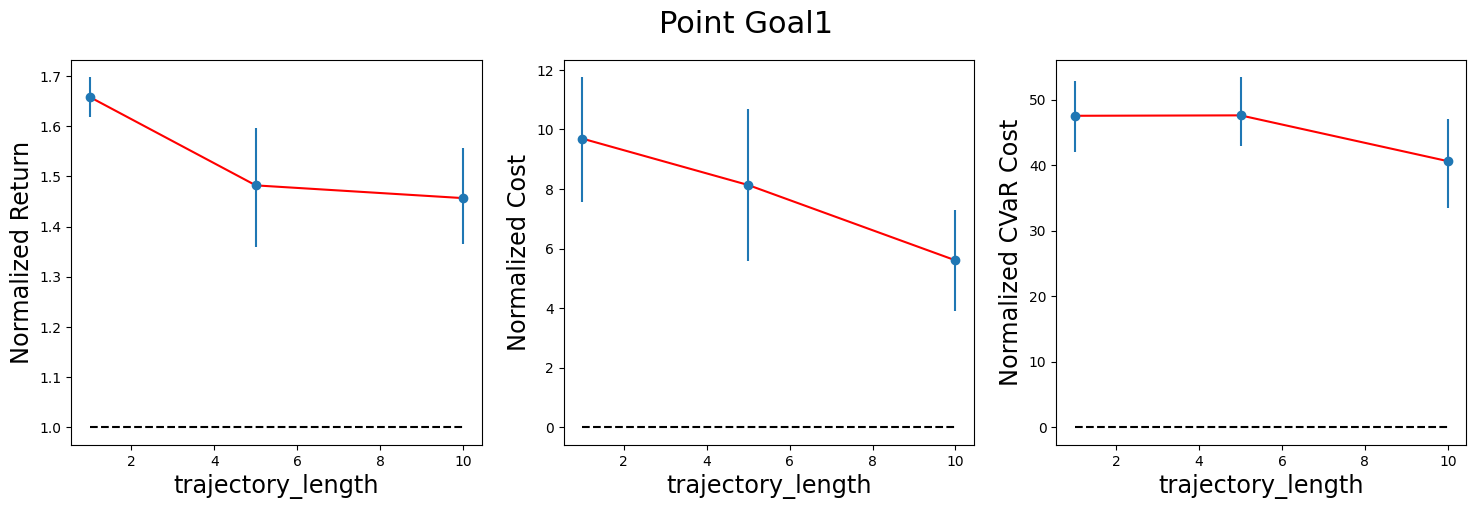

In [32]:
# tasks = ["Swimmer_Velocity",]  # Point_Goal1  Swimmer_Velocity
# algos = [
#     [("safemil/loss_1_bce/bag_1/hz_5", 1), ("safemil/loss_1_bce/bag_8/hz_5", 8), ("safemil/loss_1_bce/bag_16/hz_5", 16), ("safemil/loss_1_bce/bag_64/hz_5", 64), ("safemil/loss_1_bce/bag_128/hz_5", 128)],
#     # [("safemil/loss_1_bce/bag_1/hz_10", 1), ("safemil/loss_1_bce/bag_16/hz_10", 16), ("safemil/loss_1_bce/bag_64/hz_10", 64), ("safemil/loss_1_bce/bag_128/hz_10", 128)],
# ]
# key = "bag_size"
tasks = ["Point_Goal1",] # Point_Goal1 Swimmer_Velocity
algos = [
    [("safemil/loss_1_bce/bag_128/hz_1", 1), ("safemil/loss_1_bce/bag_128/hz_5", 5), ("safemil/loss_1_bce/bag_128/hz_10", 10)],
]
key = "trajectory_length"
fig, ax = generate_sensitivity_figure(tasks, algos, key)
fig.suptitle(tasks[0].replace("_", " "), fontsize=22)


#### Individual plots

In [ ]:
hyperparams = "mix_50p"  # "valid_mix_50p_hz_3",  "bweight_mix_50p_hz_3", "bweight_valid_mix_50p_hz_3"

task = "Point_Circle2"
type = "ep_cost"

means, lowers, uppers, labels = [], [], [], []
for a, suffix in [("bc", "bc"), ("dwbc/nu_0.5", "dwbc"), ("ppl", "ppl"), ("safedice", "safedice"), ("safemil/loss_1_bce/bag_128/hz_5", "ours")]: 
# for a, suffix in [ ("safemil/loss_1/bag_128/hz_5", "loss_1"), ("safemil/loss_1_bce/bag_128/hz_5", "loss_1_bce")]: 
# for a, suffix in [ ("dwbc/nu_0.1", "nu_0.1"), ("dwbc/nu_0.5", "nu_0.5")]: 
    data = load_data_as_array(hyperparams, a, task, type)
    m, l, u = bootstrap_confidence_interval(data)
    if type == "ep_reward":
        m, l, u = (normalize_reward(x, task) for x in (m, l, u))
    means.append(m)
    lowers.append(l)
    uppers.append(u)
    labels.append(suffix)

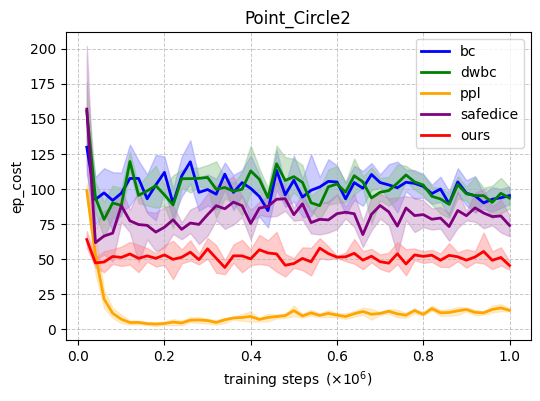

In [ ]:
colors = BASE_COLORS[:len(labels)]

fig, ax = plot_confidence_interval(means, lowers, uppers, labels=labels, colors=colors, title=f"{task}", xlabel="training steps " + r"$ \, (\times 10^6)$", ylabel=type)

#### Save figure

In [72]:
save_fig_path = f"{DATA_PATH}/pdf_images/{HYPERPARAMS}/{key}/norm_point_task.pdf"
fig.savefig(save_fig_path, format="pdf", dpi=300)

In [73]:
save_fig_path = f"{DATA_PATH}/png_images/{HYPERPARAMS}/{key}/norm_point_task.png"
fig.savefig(save_fig_path)

##### Safety-Gymnasium

In [89]:
import safety_gymnasium as safety_gym

In [115]:
def get_env_image(env_name, version, ax):
    safety_env_name = f"Safety{env_name.replace('_', '')}-v{version}"
    e = safety_gym.make(safety_env_name, render_mode="rgb_array", camera_name="fixedfar")
    e.reset()
    e.step(e.action_space.sample())
    e.step(e.action_space.sample())
    e.step(e.action_space.sample())
    e.step(e.action_space.sample())
    e.step(e.action_space.sample())
    e.step(e.action_space.sample())
    f = e.render()
    e.close()
    ax.imshow(f, cmap='viridis')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(env_name.replace("_", " "), fontsize=25)
    return ax

In [116]:
def add_env_figures(env_names, version):
    n = len(env_names)
    single_fig, single_ax = plt.subplots(1, n, figsize=(20, 8))
    for i, env_name in enumerate(env_names):
        _ = get_env_image(env_name, version, ax=single_ax[i])

    plt.subplots_adjust(hspace=0.15, wspace=0.1)
    plt.tight_layout() 
    return single_fig, single_ax

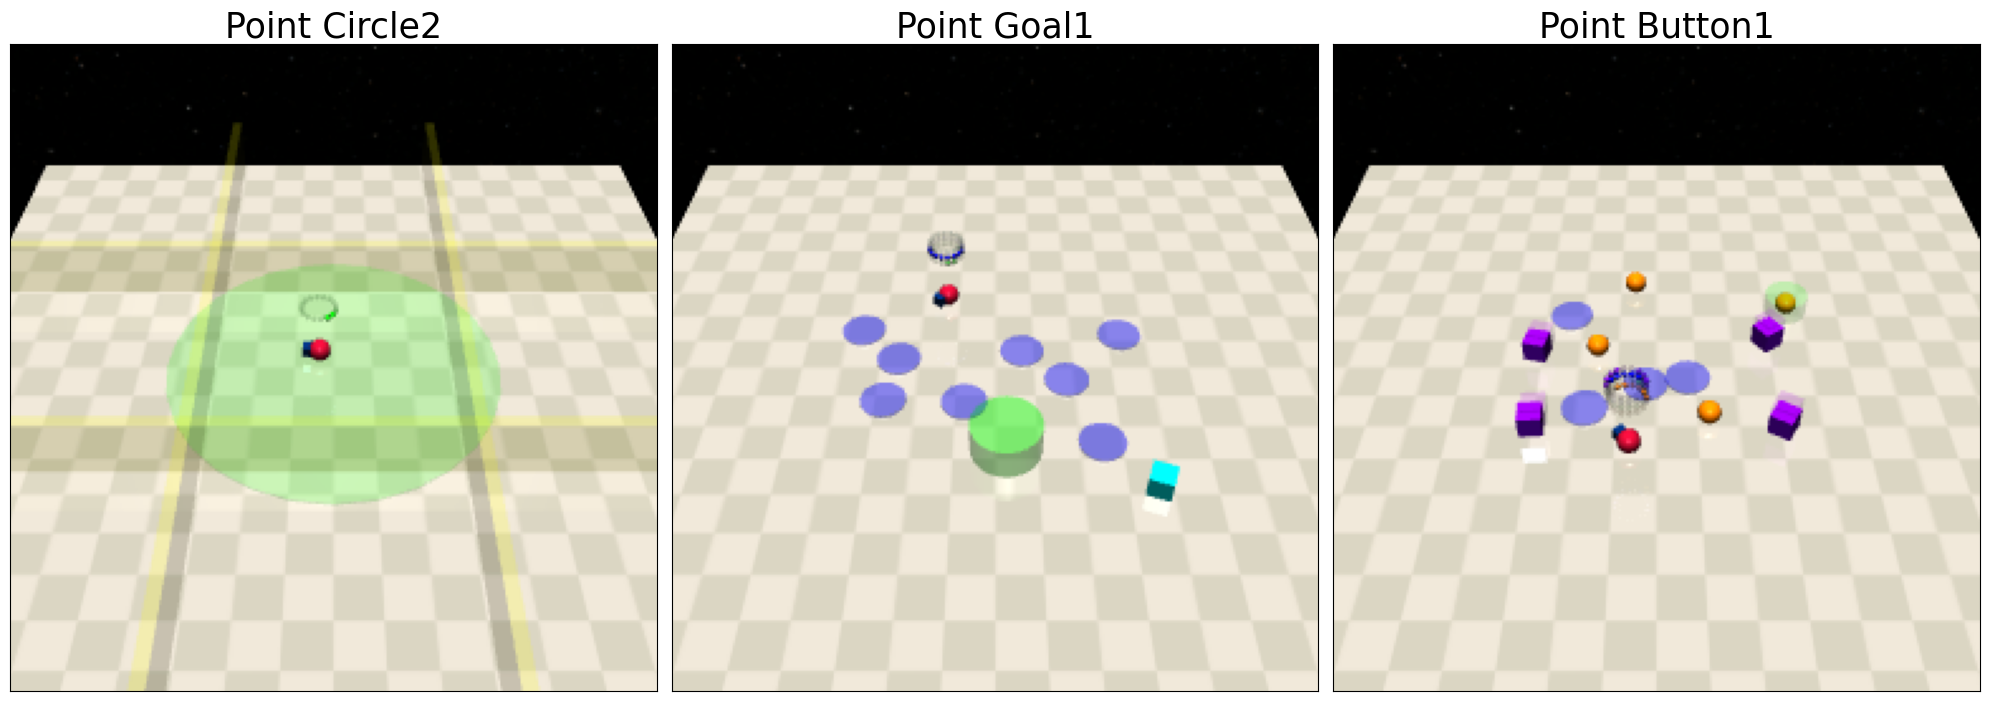

In [117]:
env_names = ["Point_Circle2", "Point_Goal1", "Point_Button1"]
# env_names = ["Walker2d_Velocity", "Swimmer_Velocity", "Ant_Velocity"] # Hopper_Velocity
version = 0
fig, ax = add_env_figures(env_names, version)


In [118]:
save_fig_path = f"{DATA_PATH}/svg_images/point_task.svg"
fig.savefig(save_fig_path, format="svg")